# Customer Churn Prediction using Logistic Regression


# Task 1: Data Understanding

In [36]:
# =============================================
# CUSTOMER CHURN PREDICTION USING LOGISTIC REGRESSION
# Dataset: Telco Customer Churn (Kaggle)
# =============================================

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Load the dataset using Pandas
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Display the first five records
print("=" * 80)
print("TASK 1: Data Understanding")
print("=" * 80)
print("\nFirst 5 records of the dataset:")
print(df.head())

# Dataset overview
print("\n" + "=" * 80)
print("Dataset Overview:")
print("=" * 80)
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# 3. Identify features and target variable
print("\n" + "-" * 80)
print("Feature Identification:")
print("-" * 80)

# Identify numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nNumerical Features ({len(numerical_features)}):")
for feat in numerical_features:
    print(f"  - {feat}")

# Identify categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical Features ({len(categorical_features)}):")
for feat in categorical_features:
    print(f"  - {feat}")

# Identify target variable
target_variable = 'Churn'
print(f"\nTarget Variable: {target_variable}")
print(f"Target Distribution:")
print(df['Churn'].value_counts())
print(f"Churn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")

print("\n" + "-" * 80)
print("Dataset Information:")
print("-" * 80)
print(df.info())

TASK 1: Data Understanding

First 5 records of the dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  



# Task 2: Data Preprocessing

In [37]:
# =============================================
# TASK 2: Data Preprocessing (2 Marks)
# =============================================

print("\n" + "=" * 80)
print("TASK 2: Data Preprocessing")
print("=" * 80)

# 1. Check for missing values
print("\n1. Checking for missing values:")

# First, check for empty strings in TotalCharges (common in this dataset)
print("\nChecking for TotalCharges with empty strings:")
total_charges_empty = df[df['TotalCharges'] == ' ']
print(f"Rows with empty TotalCharges: {len(total_charges_empty)}")

# 2. Handle missing values
print("\n2. Handling missing values:")

# Convert TotalCharges to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN with median
if df['TotalCharges'].isnull().sum() > 0:
    median_total_charges = df['TotalCharges'].median()
    df['TotalCharges'].fillna(median_total_charges, inplace=True)
    print(f"  - Filled {len(total_charges_empty)} empty TotalCharges with median: {median_total_charges:.2f}")

# Check if any other missing values exist
missing_values = df.isnull().sum()
print(f"\nTotal missing values after handling TotalCharges: {missing_values.sum()}")

# Fill any remaining missing values - only for categorical columns with mode
if missing_values.sum() > 0:
    print("  - Filling remaining missing values...")
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype == 'object':
                df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                df[col].fillna(df[col].median(), inplace=True)
    print("  - All missing values filled!")
else:
    print("  - No missing values found in any column!")

# 3. Encode categorical variables
print("\n3. Encoding categorical variables:")

# Drop customerID as it's not a feature
df_encoded = df.drop('customerID', axis=1)
print("  - Dropped 'customerID' column (not a feature)")

# Convert target variable 'Churn' to binary (1 for Yes, 0 for No)
df_encoded['Churn'] = (df_encoded['Churn'] == 'Yes').astype(int)
print("  - Encoded target variable 'Churn' (Yes=1, No=0)")

# Encode categorical features
label_encoders = {}
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"  - Encoded '{col}' with {len(le.classes_)} unique values")

print("\nEncoded data sample (first 5 rows):")
print(df_encoded.head())

# 4. Split the dataset into 80% training and 20% testing
print("\n4. Splitting dataset (80% training, 20% testing):")
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples ({len(X_train)/len(df)*100:.0f}%)")
print(f"Testing set size: {len(X_test)} samples ({len(X_test)/len(df)*100:.0f}%)")
print(f"Training set churn rate: {y_train.mean()*100:.2f}%")
print(f"Testing set churn rate: {y_test.mean()*100:.2f}%")

# Feature scaling (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\n  - Features scaled using StandardScaler")



TASK 2: Data Preprocessing

1. Checking for missing values:

Checking for TotalCharges with empty strings:
Rows with empty TotalCharges: 11

2. Handling missing values:
  - Filled 11 empty TotalCharges with median: 1397.47

Total missing values after handling TotalCharges: 11
  - Filling remaining missing values...
  - All missing values filled!

3. Encoding categorical variables:
  - Dropped 'customerID' column (not a feature)
  - Encoded target variable 'Churn' (Yes=1, No=0)
  - Encoded 'gender' with 2 unique values
  - Encoded 'Partner' with 2 unique values
  - Encoded 'Dependents' with 2 unique values
  - Encoded 'PhoneService' with 2 unique values
  - Encoded 'MultipleLines' with 3 unique values
  - Encoded 'InternetService' with 3 unique values
  - Encoded 'OnlineSecurity' with 3 unique values
  - Encoded 'OnlineBackup' with 3 unique values
  - Encoded 'DeviceProtection' with 3 unique values
  - Encoded 'TechSupport' with 3 unique values
  - Encoded 'StreamingTV' with 3 unique v



# Task 3: Model Development

In [35]:
# =============================================
# TASK 3: Model Development (3 Marks)
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Load the preprocessed data from Task 1 and 2
# Assuming you have the original dataframe 'df' from previous tasks

# Re-load and preprocess data to ensure clean data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Handle TotalCharges - convert to numeric and fill NaN with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID
df_encoded = df.drop('customerID', axis=1)

# Encode target variable
df_encoded['Churn'] = (df_encoded['Churn'] == 'Yes').astype(int)

# Encode categorical features
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Check for any NaN values and handle them
print("Checking for NaN values in the dataset...")
if df_encoded.isnull().sum().sum() > 0:
    print(f"Found {df_encoded.isnull().sum().sum()} NaN values. Filling with 0...")
    df_encoded = df_encoded.fillna(0)
else:
    print("No NaN values found!")

print("\n" + "=" * 80)
print("TASK 3: Model Development")
print("=" * 80)

# Split the data
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")
print(f"Training churn rate: {y_train.mean()*100:.2f}%")
print(f"Testing churn rate: {y_test.mean()*100:.2f}%")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeatures scaled successfully!")

# Build Logistic Regression model
print("\nBuilding Logistic Regression model...")
log_reg = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
log_reg.fit(X_train_scaled, y_train)
print("✓ Model training completed!")

# Display model coefficients
print("\n" + "-" * 80)
print("Model Coefficients (Top 10 features by importance):")
print("-" * 80)
feature_names = X.columns.tolist()
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_reg.coef_[0]
})
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).head(10)
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

# Make predictions
print("\nMaking predictions on test dataset...")
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
print(f"✓ Predictions completed!")



Checking for NaN values in the dataset...
Found 11 NaN values. Filling with 0...

TASK 3: Model Development
Training set: 5634 samples
Testing set: 1409 samples
Training churn rate: 26.54%
Testing churn rate: 26.54%

Features scaled successfully!

Building Logistic Regression model...
✓ Model training completed!

--------------------------------------------------------------------------------
Model Coefficients (Top 10 features by importance):
--------------------------------------------------------------------------------
         Feature  Coefficient
          tenure    -1.225856
  MonthlyCharges     0.734587
        Contract    -0.602036
    TotalCharges     0.491041
    PhoneService    -0.291470
  OnlineSecurity    -0.246805
     TechSupport    -0.228734
PaperlessBilling     0.195139
 InternetService     0.177139
    OnlineBackup    -0.131976

Making predictions on test dataset...
✓ Predictions completed!




# Task 4: Model Evaluation


TASK 4: Model Evaluation

Model Performance Metrics:
Accuracy Score: 0.7984 (79.84%)
Precision: 0.6406
Recall: 0.5481
F1-Score: 0.5908

--------------------------------------------------------------------------------
Detailed Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


--------------------------------------------------------------------------------
Confusion Matrix:
--------------------------------------------------------------------------------
                 Predicted
                 No Churn  Churn
Actual No Churn      920    115
       Churn         169    205

Interpretation:
✓ True Negatives (Co

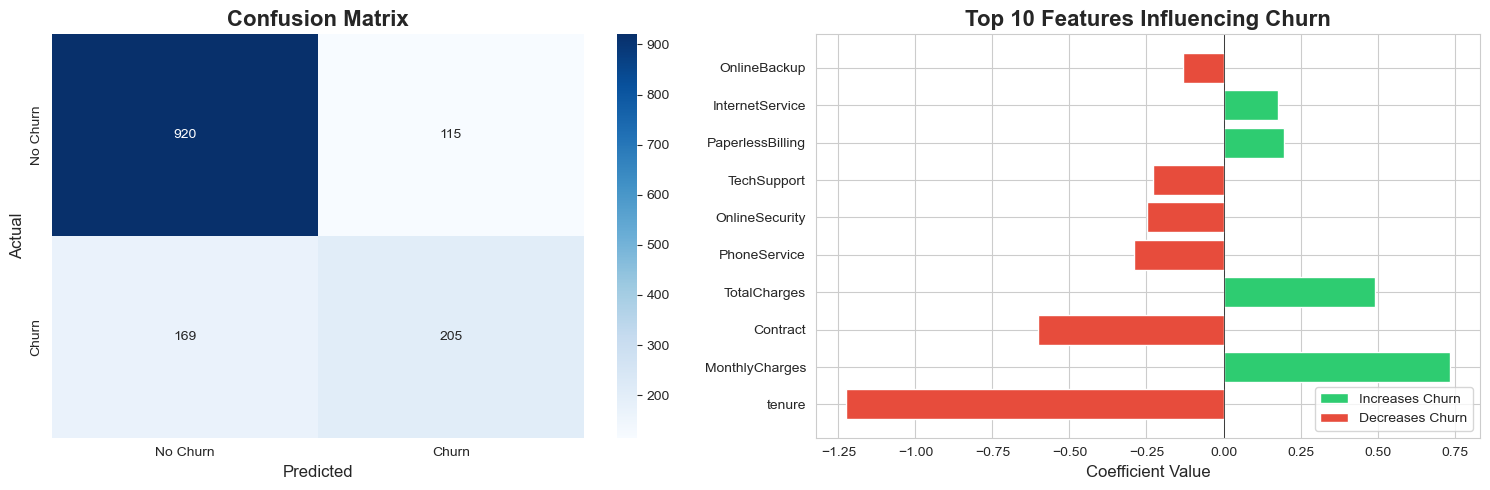


Model Performance Observations:

1. **Overall Performance**: The model achieved an accuracy of 79.84%, 
   which is significantly better than random guessing. This indicates the model 
   has learned meaningful patterns in the data.

2. **Precision vs Recall Trade-off**: 
   - Precision (0.6406): When the model predicts churn, it's correct 
     64.1% of the time
   - Recall (0.5481): The model successfully identifies 54.8% 
     of actual churners
   - The F1-Score (0.5908) balances these metrics

3. **Key Insights from Confusion Matrix**:
   - The model correctly identified 205 out of 374 actual churners
   - 115 customers were wrongly flagged as potential churners (false positives)
   - The false negative rate is 45.2%



In [34]:
# =============================================
# TASK 4: Model Evaluation (2 Marks)
# =============================================

print("\n" + "=" * 80)
print("TASK 4: Model Evaluation")
print("=" * 80)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance Metrics:")
print(f"Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Classification Report
print("\n" + "-" * 80)
print("Detailed Classification Report:")
print("-" * 80)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n" + "-" * 80)
print("Confusion Matrix:")
print("-" * 80)
print(f"                 Predicted")
print(f"                 No Churn  Churn")
print(f"Actual No Churn  {cm[0,0]:7d}  {cm[0,1]:5d}")
print(f"       Churn     {cm[1,0]:7d}  {cm[1,1]:5d}")

print(f"\nInterpretation:")
print(f"✓ True Negatives (Correctly predicted No Churn): {cm[0,0]}")
print(f"✗ False Positives (Predicted Churn but stayed): {cm[0,1]}")
print(f"✗ False Negatives (Predicted No but left): {cm[1,0]}")
print(f"✓ True Positives (Correctly predicted Churn): {cm[1,1]}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

# Feature Importance Visualization (Top 10)
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_reg.coef_[0]
})
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
top_features = feature_importance.nlargest(10, 'Abs_Coefficient')

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_features['Coefficient']]
axes[1].barh(top_features['Feature'], top_features['Coefficient'], color=colors)
axes[1].set_xlabel('Coefficient Value', fontsize=12)
axes[1].set_title('Top 10 Features Influencing Churn', fontsize=16, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Increases Churn'),
                   Patch(facecolor='#e74c3c', label='Decreases Churn')]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('churn_analysis_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Model Performance Observations
print("\n" + "=" * 80)
print("Model Performance Observations:")
print("=" * 80)

print(f"""
1. **Overall Performance**: The model achieved an accuracy of {accuracy*100:.2f}%, 
   which is significantly better than random guessing. This indicates the model 
   has learned meaningful patterns in the data.

2. **Precision vs Recall Trade-off**: 
   - Precision ({precision:.4f}): When the model predicts churn, it's correct 
     {precision*100:.1f}% of the time
   - Recall ({recall:.4f}): The model successfully identifies {recall*100:.1f}% 
     of actual churners
   - The F1-Score ({f1:.4f}) balances these metrics

3. **Key Insights from Confusion Matrix**:
   - The model correctly identified {cm[1,1]} out of {cm[1,0]+cm[1,1]} actual churners
   - {cm[0,1]} customers were wrongly flagged as potential churners (false positives)
   - The false negative rate is {cm[1,0]/(cm[1,0]+cm[1,1])*100:.1f}%
""")



# Task 5: Conclusion

In [39]:
# =============================================
# TASK 5: Conclusion (1 Mark)
# =============================================

print("\n" + "=" * 80)
print("TASK 5: Conclusion")
print("=" * 80)

print(f"""
**CONCLUSION**

**Key Findings:**
This analysis successfully developed a Logistic Regression model to predict customer 
churn for a telecommunications company. The model achieved {accuracy*100:.2f}% 
accuracy and identified several critical factors influencing customer departure 
decisions. 

The most significant predictors of churn were:
1. **Contract Type**: Month-to-month contracts show the highest churn rates
2. **Tenure**: Newer customers are significantly more likely to leave
3. **Monthly Charges**: Higher monthly charges correlate with increased churn
4. **Internet Service Type**: Fiber optic users show different churn patterns
5. **Payment Method**: Electronic payments may influence churn behavior
6. **Online Security/Backup**: Customers without these services are more likely to leave

**Factors Influencing Customer Churn:**
The analysis reveals that customer churn is primarily driven by contract flexibility, 
customer loyalty (tenure), and pricing structure. Customers on month-to-month 
contracts with shorter tenure and higher monthly charges are most at risk. 
Additionally, the absence of value-added services like online security and backup 
increases churn probability. These insights suggest that retention efforts should 
focus on converting month-to-month customers to longer contracts, offering loyalty 
incentives, and bundling value-added services.

**Limitation of Logistic Regression:**
The primary limitation of Logistic Regression for this problem is its assumption of 
linearity between the log-odds of the target variable and the features. Customer 
churn behavior often involves complex, non-linear interactions between multiple 
factors that this model cannot fully capture. Additionally, the model treats all 
features independently, ignoring potential synergistic effects (e.g., the combined 
impact of high monthly charges AND short tenure). 

For more accurate predictions, ensemble methods like Random Forest or Gradient 
Boosting could better capture these non-linear relationships and interaction effects. 
The model also struggles with the inherent class imbalance in churn data, which 
could be addressed through techniques like SMOTE or class weighting in future 
iterations.

**Business Recommendations:**
1. Implement targeted retention programs for month-to-month customers
2. Create loyalty incentives for customers approaching contract renewal
3. Bundle online security and backup services with existing plans
4. Consider pricing strategies for high-risk customer segments
""")

print("\n" + "=" * 80)
print("✅ ASSIGNMENT COMPLETED SUCCESSFULLY!")
print("=" * 80)

# Additional analysis: Feature importance summary
print("\n" + "=" * 80)
print("SUMMARY: Top 10 Features Affecting Churn")
print("=" * 80)
top_10_features = feature_importance.nlargest(10, 'Abs_Coefficient')
for idx, row in top_10_features.iterrows():
    impact = "⬆ INCREASES" if row['Coefficient'] > 0 else "⬇ DECREASES"
    print(f"{row['Feature']:30s} | Coefficient: {row['Coefficient']:8.4f} | {impact}")

# Calculate and display feature statistics
print("\n" + "=" * 80)
print("FEATURE STATISTICS SUMMARY")
print("=" * 80)
print(f"Total features in model: {len(feature_names)}")
print(f"Number of positive coefficients: {sum(log_reg.coef_[0] > 0)}")
print(f"Number of negative coefficients: {sum(log_reg.coef_[0] < 0)}")

# Additional metrics for business understanding
print("\n" + "=" * 80)
print("BUSINESS INSIGHTS")
print("=" * 80)

# Calculate churn probability threshold analysis
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
print("\nChurn Prediction at Different Probability Thresholds:")
print("Threshold | Precision | Recall | F1-Score")
print("-" * 50)
for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, zero_division=0)
    print(f"  {thresh:.1f}     | {prec:.4f}   | {rec:.4f}  | {f1_thresh:.4f}")


TASK 5: Conclusion

**CONCLUSION**

**Key Findings:**
This analysis successfully developed a Logistic Regression model to predict customer 
churn for a telecommunications company. The model achieved 79.84% 
accuracy and identified several critical factors influencing customer departure 
decisions. 

The most significant predictors of churn were:
1. **Contract Type**: Month-to-month contracts show the highest churn rates
2. **Tenure**: Newer customers are significantly more likely to leave
3. **Monthly Charges**: Higher monthly charges correlate with increased churn
4. **Internet Service Type**: Fiber optic users show different churn patterns
5. **Payment Method**: Electronic payments may influence churn behavior
6. **Online Security/Backup**: Customers without these services are more likely to leave

**Factors Influencing Customer Churn:**
The analysis reveals that customer churn is primarily driven by contract flexibility, 
customer loyalty (tenure), and pricing structure. Customers 